# Probabilistic Day-Ahead Electricity Load Forecasting

**Spectral structure, transparent benchmarks and calibration on Belgian grid data.**

Electricity demand is strongly periodic, but periodicity is not the same as
predictability. This study asks how much of Belgian quarter-hourly load can be
forecast one day ahead from temporal structure alone, and whether the resulting
uncertainty estimates are statistically calibrated.

Before building anything, increment 1 audits what is already in the data: Elia
publishes an operational day-ahead forecast with P10/P90 bounds. That is a
professional reference — and a calibration question in its own right.

Companion study: [ElectricityResourceAdequacy](https://github.com/evrelegh/ElectricityResourceAdequacy)
— the same Fourier transform, used to convolve random variables rather than to
decompose temporal structure.

*Increment 1 — cells 01–05: acquisition, integrity, Elia audit, first figures.
No forecasting model yet.*


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 01 · §0 · Forecast contract & configuration                    v1.5.0
# provides ▸ np · pd · plt · requests · elf.* · ELIA_BASE · ZONE · YEARS
#            TZ · H_ALIGN · FREQ · ORIGIN_CIVIL_HOUR · ORIGIN_CANDIDATES
#            CACHE · RNG · DS_LOAD
# requires ▸ —
# ══════════════════════════════════════════════════════════════════════════
import warnings, os, pathlib
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Extracted core — general behaviour lives in the package and is unit
# tested there; the notebook keeps the narrative and the data contracts.
from electricity_load_forecasting.baselines import (
    daily_origin, origin_violations, seasonal_naive)
from electricity_load_forecasting.fourier import (
    SPEC, design_matrix, forecast_by_origin)
from electricity_load_forecasting.calendar import (
    be_holidays, civil_features, complete_civil_days, easter, expected_slots)
from electricity_load_forecasting.metrics import (
    coverage, interval_width, pinball, score, score_point, score_prob)
from electricity_load_forecasting.spectral import (
    dominant_periods, fill_short_gaps, periodogram)

warnings.filterwarnings("ignore", message='Creating legend with loc="best"')

# --- zone & analysis window -------------------------------------------------
ZONE  = "BE"
YEARS = [2023]                       # multi-year capable; widen once v1 runs
START = pd.Timestamp(f"{min(YEARS)}-01-01")    # civil analysis window
END   = pd.Timestamp(f"{max(YEARS)}-12-31")
# Belgium is UTC+1/+2, so a UTC calendar year is not a civil year: pull with a
# month of margin either side and trim to complete civil days in CELL 03.
FETCH_START = (START - pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")
FETCH_END   = (END   + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")

# --- the forecast contract --------------------------------------------------
# Fixed daily origin; target is the next civil day at quarter-hour resolution.
# Every feature for target T+h must be available at T. Enforced in CELL 07.
# Target is the FULL next Belgian civil day, so the number of horizons is a
# property of the calendar, not a constant: H_D = 92 / 96 / 100 at the DST
# transitions. H_ALIGN is only for horizon-resolved reporting, where the two
# odd days are excluded so every h carries the same sample size.
H_ALIGN = 96
FREQ    = "15min"
TZ   = "Europe/Brussels"             # civil time — calendar features only
                                     # UTC stays the computational time axis
# Forecast origin, read from the dataset's own field-level metadata.
#
# The ODS001 schema labels the three columns this study uses:
#     dayaheadforecast      -> "Day-ahead 6PM forecast"
#     dayaheadconfidence10  -> "Day-ahead 6PM P10"
#     dayaheadconfidence90  -> "Day-ahead 6PM P90"
# The forecast for day D is therefore issued at 18:00 civil time on D-1.
#   Elia Open Data, ODS001 metadata and JSON schema:
#   https://opendata.elia.be/explore/dataset/ods001/information/
# The same 6PM naming runs through Elia's open data generally, where day-ahead
# 11h and day-ahead 6PM appear as distinct published horizons.
#
# Elia's general grid-data page for load describes a day-ahead load forecast
# updated at midday, and an earlier revision of that page said 08:45. That page
# documents the load graph on the Elia website rather than these columns, and
# may describe a different product or a later publication schedule; the
# field-level metadata is the specific authority for the data actually used
# here. The alternative times are retained in CELL 10 as a robustness check,
# not as competing readings of this column.
#   https://www.elia.be/en/grid-data/load-and-load-forecasts
ORIGIN_CIVIL_HOUR = 18
ORIGIN_CANDIDATES = {"08:45 (Elia load page, earlier revision)": 8.75,
                     "12:00 (Elia load page, current)": 12.0,
                     "18:00 (ODS001 schema — primary)": 18.0}

# --- data endpoints ---------------------------------------------------------
ELIA_BASE = "https://opendata.elia.be/api/explore/v2.1"   # Opendatasoft, no token
DS_LOAD   = "ods001"                                      # measured + forecast load, BE

CACHE = pathlib.Path("cache"); CACHE.mkdir(exist_ok=True)
RNG   = np.random.default_rng(7)

print(f"zone={ZONE}  civil={START:%Y-%m-%d}..{END:%Y-%m-%d}  fetch={FETCH_START}..{FETCH_END}  H_align={H_ALIGN}  tz={TZ}")


zone=BE  civil=2023-01-01..2023-12-31  fetch=2022-12-01..2024-01-31  H_align=96  tz=Europe/Brussels


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 02 · §1 · Elia open-data client + cached pull                  v1.2.0
# provides ▸ elia_catalog · elia_peek · elia_fetch · _csv · LOAD
# requires ▸ requests · pd · ELIA_BASE · DS_LOAD · FETCH_START · FETCH_END · CACHE
# ══════════════════════════════════════════════════════════════════════════
# Client carried over unchanged from ElectricityResourceAdequacy CELL 02.
from time import sleep

def elia_catalog(query, limit=8):
    """List Elia datasets whose metadata matches `query` (id + title)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets",
                     params={"where": f'"{query}"', "limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.DataFrame([{"dataset_id": d["dataset_id"],
                          "title": d.get("metas", {}).get("default", {}).get("title", "")}
                         for d in r.json().get("results", [])])

def elia_peek(dataset_id, limit=5):
    """A few records to reveal the field names / schema (fast, no bulk)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets/{dataset_id}/records",
                     params={"limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.json_normalize(r.json().get("results", []))

def _csv(dataset_id, where="", order_by="", tries=4):
    """One streamed CSV-export request, retried on a dropped connection."""
    params = {k: v for k, v in dict(where=where, order_by=order_by).items() if v}
    url = f"{ELIA_BASE}/catalog/datasets/{dataset_id}/exports/csv"
    for a in range(1, tries + 1):
        try:
            with requests.get(url, params=params, timeout=300, stream=True) as r:
                r.raise_for_status()
                buf = StringIO()
                for chunk in r.iter_content(chunk_size=1 << 16, decode_unicode=True):
                    if chunk:
                        buf.write(chunk)
            buf.seek(0)
            return pd.read_csv(buf, sep=";")
        except (requests.exceptions.ChunkedEncodingError,
                requests.exceptions.ConnectionError,
                requests.exceptions.Timeout) as e:
            if a == tries:
                raise
            print(f"    {dataset_id}: {type(e).__name__} — retry {a}/{tries}")
            sleep(2 * a)

def elia_fetch(dataset_id, start, end):
    """Full series over [start, end], pulled MONTH BY MONTH and concatenated —
    small requests that survive where one giant export drops. Time field auto-detected."""
    cols = list(elia_peek(dataset_id, 1).columns)
    ts = next((c for c in cols if "datetime" in c.lower()
               or c.lower() in ("date", "timestamp")), None)
    if ts is None:
        raise ValueError(f"{dataset_id}: no time field in {cols}")
    edges = pd.date_range(pd.Timestamp(start).replace(day=1),
                          pd.Timestamp(end) + pd.offsets.MonthBegin(1), freq="MS")
    parts = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        w = f"{ts} >= '{lo:%Y-%m-%d}' AND {ts} < '{hi:%Y-%m-%d}'"
        d = _csv(dataset_id, where=w, order_by=ts)
        print(f"    {dataset_id} {lo:%Y-%m}: {len(d):6d} rows")
        parts.append(d)
    return pd.concat(parts, ignore_index=True)

# --- cached acquisition -----------------------------------------------------
def cached_fetch(dataset_id, start, end, refresh=False):
    """Pull once, reuse thereafter. Raw payload only — no transformation here."""
    f = CACHE / f"{dataset_id}_{start}_{end}.csv.gz"
    if f.exists() and not refresh:
        print(f"cache hit  {f.name}")
        return pd.read_csv(f)
    print(f"--- {dataset_id} schema ---")
    print(list(elia_peek(dataset_id).columns))
    df = elia_fetch(dataset_id, start, end)
    df.to_csv(f, index=False, compression="gzip")
    print(f"cached     {f.name}  {df.shape}")
    return df

# Cache first: with a warm cache the notebook runs with no network at all,
# which is what makes the study reproducible rather than merely repeatable.
LOAD = cached_fetch(DS_LOAD, FETCH_START, FETCH_END)
print(f"\nLOAD: {LOAD.shape}")
print(f"columns: {list(LOAD.columns)}")
print(LOAD.head(3).to_string(index=False))


cache hit  ods001_2022-12-01_2024-01-31.csv.gz

LOAD: (40992, 10)
columns: ['datetime', 'resolutioncode', 'totalload', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadforecast']
                 datetime resolutioncode  totalload  mostrecentforecast  mostrecentconfidence10  mostrecentconfidence90  dayaheadforecast  dayaheadconfidence10  dayaheadconfidence90  weekaheadforecast
2022-12-01T00:00:00+00:00          PT15M    8596.34             8581.62                 8280.42                 8882.81           8413.73               7933.13               8894.33            8340.27
2022-12-01T00:15:00+00:00          PT15M    8448.22             8478.64                 8181.06                 8776.22           8333.17               7857.17               8809.17            8254.74
2022-12-01T00:30:00+00:00          PT15M    8378.37             8402.60                 8107.69                 869

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 03 · §1 · Data integrity — hard gate on the time axis          v1.2.0
# provides ▸ S · L · HOL
# requires ▸ LOAD · pd · np · TZ · FREQ · START · END
# ══════════════════════════════════════════════════════════════════════════
# Nothing downstream is trusted unless this cell passes. Failures raise.

FIELDS = {"y": "totalload", "yhat_da": "dayaheadforecast",
          "q10_da": "dayaheadconfidence10", "q90_da": "dayaheadconfidence90"}

missing = [c for c in FIELDS.values() if c not in LOAD.columns]
assert not missing, f"ods001 missing expected fields: {missing}\ngot: {list(LOAD.columns)}"

S = (LOAD.assign(datetime=pd.to_datetime(LOAD["datetime"], utc=True))
         .rename(columns={v: k for k, v in FIELDS.items()})
         [["datetime", *FIELDS.keys()]]
         .sort_values("datetime").reset_index(drop=True))

# --- time-axis gate ---------------------------------------------------------
assert S["datetime"].is_unique, (
    f"duplicate timestamps: {int(S['datetime'].duplicated().sum())} — "
    "check ods001 for a resolutioncode/region split")
assert S["datetime"].is_monotonic_increasing, "timestamps not sorted"

# Uniform spacing on the UTC axis is the strong gate: it makes the series a
# contiguous grid, and tz_convert only relabels it. A missing quarter shows up
# here as a 30-min step, so no separate civil-grid test is needed downstream.
gaps = S["datetime"].diff().dropna()
bad_gap = gaps[gaps != pd.Timedelta(FREQ)]
assert bad_gap.empty, (
    f"irregular spacing on the UTC axis — {len(bad_gap)} step(s), "
    f"sizes {sorted(set(bad_gap))[:5]}, first at "
    f"{S.loc[bad_gap.index[0], 'datetime']}")

# --- civil-time calendar features ------------------------------------------
# easter / be_holidays / expected_slots now live in the package: general
# behaviour, tested in tests/test_calendar.py rather than asserted here.
S = pd.concat([S, civil_features(S["datetime"], TZ)], axis=1)

# --- trim to complete civil days inside the analysis window ----------------
# A civil day is 96 quarters except at the DST transitions (92 / 100). Length
# is derived from the zone itself, not asserted. Partial days at the fetch
# boundary are dropped: a 96-quarter lag across them would be silently wrong.
# The rule lives in the package because CELL 09 applies it to a wider window.
L, incomplete = complete_civil_days(S, START, END, TZ, FREQ)
if len(incomplete):
    print("dropped incomplete civil days:",
          dict(zip(incomplete.index.strftime("%Y-%m-%d"), incomplete.values)))

per_day = L.groupby("civil_date").size()
exp = per_day.index.to_series().map(lambda d: expected_slots(d, TZ, FREQ))
assert (per_day == exp).all(), f"incomplete civil days remain:\n{per_day[per_day != exp]}"
assert L["qod"].between(0, 95).all(), "quarter-of-day outside 0..95"
dst = per_day[per_day != 96]
print(f"complete civil days: {len(per_day)}  slots: {len(L)}")
print("DST days:", dict(zip(dst.index.strftime("%Y-%m-%d"), dst.values)) or "none")

HOL = be_holidays(sorted({*L["civil_date"].dt.year}))
L["is_holiday"] = L["civil_date"].isin(HOL)

# --- published quantile ordering -------------------------------------------
band = L.dropna(subset=["q10_da", "q90_da"])
bad = int((band["q10_da"] > band["q90_da"]).sum())
assert bad == 0, f"{bad} slots with published P10 > P90"

# --- missingness, reported not silently dropped -----------------------------
print("\nmissing per field:")
print(L[list(FIELDS)].isna().sum().to_string())
print(f"\nL: {L.shape}  {L['datetime'].min()} .. {L['datetime'].max()}")
print(f"holidays in window: {len(HOL[(HOL >= L['civil_date'].min()) & (HOL <= L['civil_date'].max())])}")


complete civil days: 365  slots: 35040
DST days: {'2023-03-26': np.int64(92), '2023-10-29': np.int64(100)}

missing per field:
y          3
yhat_da    0
q10_da     0
q90_da     0

L: (35040, 12)  2022-12-31 23:00:00+00:00 .. 2023-12-31 22:45:00+00:00
holidays in window: 10


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 04 · §2 · Elia day-ahead audit — accuracy and calibration      v1.1.0
# provides ▸ A · elia_overall · common · by_hour · by_month · by_daytype
# requires ▸ L · pd · np
# ══════════════════════════════════════════════════════════════════════════
# No model of our own yet. What does the operational forecast already deliver?
# Scoring functions come from the package; only the dataset-specific
# assumptions and stratifiers belong here.

# ASSUMPTION (to confirm against Elia metadata, as with the forecast origin):
# `dayaheadconfidence10/90` are treated here as the 10th and 90th percentiles
# of Elia's predictive distribution, hence a nominal 80% central interval.
A = L.dropna(subset=["y", "yhat_da"]).copy()
A["e"] = A["y"] - A["yhat_da"]
A["inside"] = (A["y"] >= A["q10_da"]) & (A["y"] <= A["q90_da"])

# Ex-post diagnostic stratifier: realised load is not available at forecast
# time, so this is for reading the error, never a feature. The forecast-load
# decile is the ex-ante operational counterpart.
A["realised_load_decile"] = pd.qcut(A["y"], 10, labels=False, duplicates="drop")
A["forecast_load_decile"] = pd.qcut(A["yhat_da"], 10, labels=False, duplicates="drop")
A["daytype"] = np.where(A["is_holiday"], "holiday",
                np.where(A["is_weekend"], "weekend", "working day"))

elia_overall = score(A)
print("Elia day-ahead — overall")
print(elia_overall.round(3).to_string())
print(f"\nnominal P10-P90 coverage = 0.80  ·  realised = {elia_overall['cov']:.3f}")

# Same metrics restricted to the common sample, so any population difference
# between the point and probabilistic figures above is visible, not implicit.
common = A.dropna(subset=["y", "yhat_da", "q10_da", "q90_da"])
if len(common) != int(elia_overall["n_point"]):
    print(f"\npoint sample {int(elia_overall['n_point'])} vs common sample {len(common)}"
          f" — point metrics on the common sample:")
    print(score_point(common).round(3).to_string())
else:
    print("\npoint and probabilistic samples coincide")

def by(key, label=None):
    t = A.groupby(key).apply(score).round(3)
    print(f"\n--- by {label or key} ---")
    print(t.to_string())
    return t

by_hour    = by("hour", "hour of civil day")
by_month   = by("month")
by_daytype = by("daytype", "day type")
by_rdecile = by("realised_load_decile", "realised-load decile (ex post)")
by_fdecile = by("forecast_load_decile", "forecast-load decile (ex ante)")

# Conditional coverage is where an overall 80% can hide an operational problem.
print("\n--- P10-P90 coverage, worst 8 hour x season cells ---")
A["season"] = A["month"].map({12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
                              6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"})
cc = (A.groupby(["season", "hour"])
        .agg(cov=("inside", "mean"), n=("inside", "size")).reset_index())
print(cc.nsmallest(8, "cov").round(3).to_string(index=False))


Elia day-ahead — overall
n_point     35037.000
bias          -59.860
MAE           259.865
RMSE          341.957
n_prob      35037.000
cov             0.721
width         745.847
pin_lo         65.530
pin_hi         61.885
pin_mean       63.708

nominal P10-P90 coverage = 0.80  ·  realised = 0.721

point and probabilistic samples coincide

--- by hour of civil day ---
      n_point     bias      MAE     RMSE  n_prob    cov    width  pin_lo  pin_hi  pin_mean
hour                                                                                      
0      1460.0 -104.182  230.530  298.317  1460.0  0.801  753.914  54.804  54.052    54.428
1      1460.0  -83.513  222.706  297.914  1460.0  0.771  723.958  58.044  53.034    55.539
2      1460.0  -77.266  217.158  302.651  1460.0  0.751  685.801  61.899  52.944    57.422
3      1460.0  -72.716  216.179  301.979  1460.0  0.753  684.099  61.083  52.713    56.898
4      1460.0  -76.371  217.381  305.217  1460.0  0.758  684.110  61.254  53.850   


--- by forecast-load decile (ex ante) ---
                      n_point    bias      MAE     RMSE  n_prob    cov    width  pin_lo  pin_hi  pin_mean
forecast_load_decile                                                                                     
0                      3504.0 -74.160  242.693  335.357  3504.0  0.733  687.222  58.883  62.363    60.623
1                      3504.0 -90.291  247.937  333.986  3504.0  0.734  711.025  60.945  62.019    61.482
2                      3503.0 -87.090  263.229  349.489  3503.0  0.681  696.513  64.814  66.556    65.685
3                      3504.0 -87.422  284.918  377.935  3504.0  0.680  713.602  72.785  67.953    70.369
4                      3504.0 -60.706  308.713  411.638  3504.0  0.687  781.324  80.384  71.116    75.750
5                      3503.0 -87.667  265.725  347.209  3503.0  0.729  796.648  69.493  60.021    64.757
6                      3504.0 -79.424  233.253  296.782  3504.0  0.779  768.275  54.190  55.217    54.704
7  

season  hour   cov   n
   JJA    17 0.546 368
   JJA    10 0.557 368
   JJA    16 0.571 368
   JJA     9 0.582 368
   JJA    14 0.587 368
   MAM    17 0.603 368
   MAM    14 0.606 368
   MAM    15 0.606 368


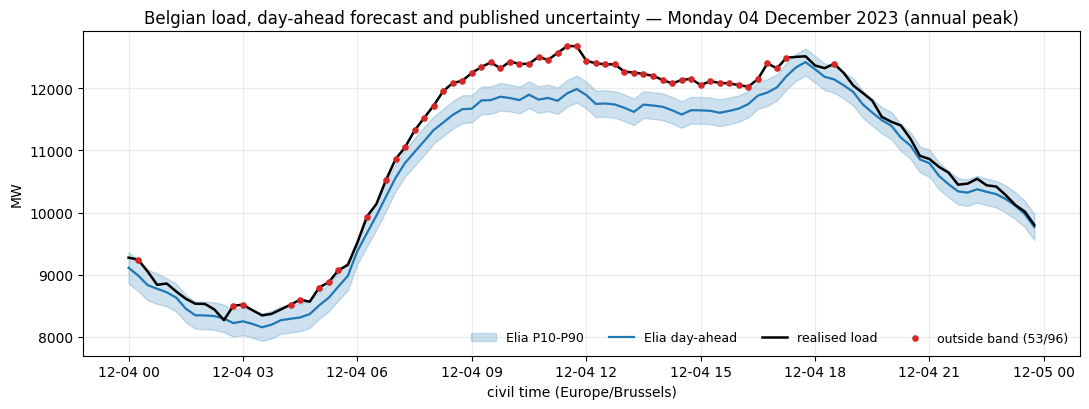

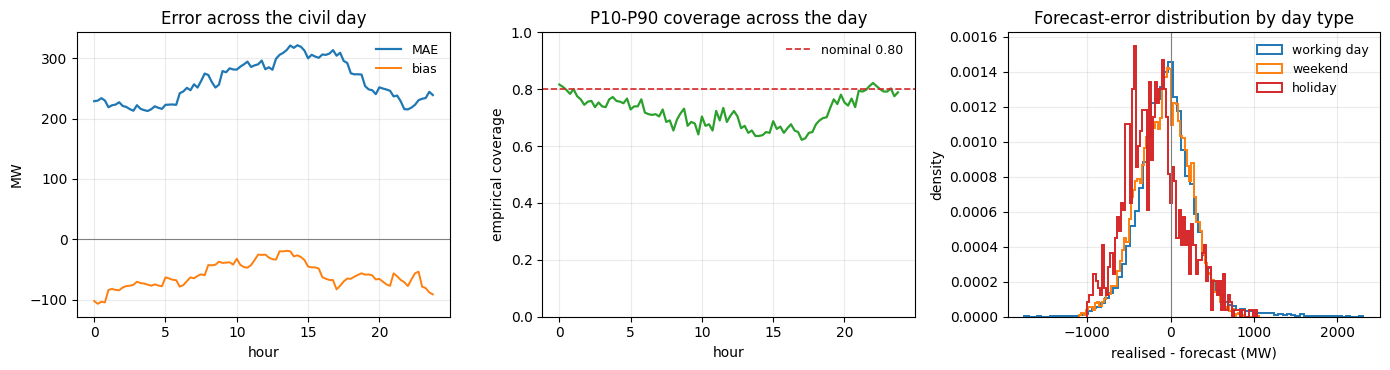

annual peak day: 2023-12-04  peak = 12,681 MW
widest band day: 2023-12-29


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 05 · §3 · First figures — is the data interesting?             v1.0.0
# provides ▸ —   ·   requires ▸ A · by_hour · plt · np · pd · TZ
# ══════════════════════════════════════════════════════════════════════════
# One day in full, then the shape of the error and the band across the day.

peak_day = A.loc[A["y"].idxmax(), "civil_date"]
d = A[A["civil_date"] == peak_day].copy()
d["t"] = d["datetime"].dt.tz_convert(TZ)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(d["t"], d["q10_da"], d["q90_da"], alpha=.22, color="tab:blue",
                label="Elia P10-P90")
ax.plot(d["t"], d["yhat_da"], color="tab:blue", lw=1.6, label="Elia day-ahead")
ax.plot(d["t"], d["y"], color="black", lw=1.8, label="realised load")
out = d[~d["inside"]]
ax.scatter(out["t"], out["y"], s=14, color="tab:red", zorder=5,
           label=f"outside band ({len(out)}/{len(d)})")
ax.set(title=f"Belgian load, day-ahead forecast and published uncertainty — "
             f"{peak_day:%A %d %B %Y} (annual peak)",
       xlabel=f"civil time ({TZ})", ylabel="MW")
ax.legend(frameon=False, ncol=4, fontsize=9); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

q = A.groupby("qod").agg(mae=("e", lambda s: s.abs().mean()),
                         bias=("e", "mean"))
axes[0].plot(q.index / 4, q["mae"], color="tab:blue", lw=1.6, label="MAE")
axes[0].plot(q.index / 4, q["bias"], color="tab:orange", lw=1.4, label="bias")
axes[0].axhline(0, color="grey", lw=.8)
axes[0].set(title="Error across the civil day", xlabel="hour", ylabel="MW")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=.25)

c = A.groupby("qod")["inside"].mean()
axes[1].plot(c.index / 4, c, color="tab:green", lw=1.6)
axes[1].axhline(.80, color="tab:red", ls="--", lw=1.2, label="nominal 0.80")
axes[1].set(title="P10-P90 coverage across the day", xlabel="hour",
            ylabel="empirical coverage", ylim=(0, 1))
axes[1].legend(frameon=False, fontsize=9); axes[1].grid(alpha=.25)

for dt, col in [("working day", "tab:blue"), ("weekend", "tab:orange"),
                ("holiday", "tab:red")]:
    s = A[A["daytype"] == dt]
    if len(s):
        axes[2].hist(s["e"], bins=80, histtype="step", density=True,
                     color=col, lw=1.4, label=dt)
axes[2].axvline(0, color="grey", lw=.8)
axes[2].set(title="Forecast-error distribution by day type", xlabel="realised - forecast (MW)",
            ylabel="density")
axes[2].legend(frameon=False, fontsize=9); axes[2].grid(alpha=.25)

plt.tight_layout(); plt.show()

print(f"annual peak day: {peak_day:%Y-%m-%d}  peak = {A['y'].max():,.0f} MW")
print(f"widest band day: {A.groupby('civil_date').apply(lambda g: (g.q90_da - g.q10_da).mean()).idxmax():%Y-%m-%d}")


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 06 · §4 · Spectral preparation — a gapless uniform grid        v1.0.0
# provides ▸ Y_LIN · Y_WK · FILLED · FS   ·   requires ▸ L · fill_short_gaps
# ══════════════════════════════════════════════════════════════════════════
# The FFT needs a uniform grid with no holes. Three realised-load slots are
# missing, so they are filled — deliberately, and twice by unrelated means, so
# that any spectral conclusion can be shown not to rest on the interpolation.
# A run longer than one hour would raise instead of being smoothed over.

FS = 96.0                                   # samples per day on the UTC axis

Y_LIN, FILLED = fill_short_gaps(L["y"].to_numpy(), max_gap=4, method="linear")
Y_WK,  _      = fill_short_gaps(L["y"].to_numpy(), max_gap=4, method="weekly")

gaps = L.loc[FILLED, ["datetime", "civil_date", "qod"]].copy()
gaps["linear"] = Y_LIN[FILLED]
gaps["weekly"] = Y_WK[FILLED]
gaps["diff_MW"] = gaps["linear"] - gaps["weekly"]

print(f"filled {int(FILLED.sum())} of {len(L)} slots "
      f"({FILLED.sum() / len(L):.4%} of the series)")
print(gaps.to_string(index=False))
print(f"\nlargest disagreement between the two fills: "
      f"{gaps['diff_MW'].abs().max():.1f} MW")
print(f"series std: {np.nanstd(L['y']):.1f} MW — the fills differ by a small "
      f"fraction of one standard deviation, on 3 of {len(L)} points")


filled 3 of 35040 slots (0.0086% of the series)
                 datetime civil_date  qod    linear  weekly  diff_MW
2023-08-10 09:00:00+00:00 2023-08-10   44  8787.545 8688.15   99.395
2023-08-11 09:00:00+00:00 2023-08-11   44  9148.695 8803.79  344.905
2023-09-11 09:00:00+00:00 2023-09-11   44 11141.125 9731.21 1409.915

largest disagreement between the two fills: 1409.9 MW
series std: 1353.1 MW — the fills differ by a small fraction of one standard deviation, on 3 of 35040 points


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 07 · §4 · Periodogram and the periods the data actually contains v1.0.0
# provides ▸ FRQ · PSD · PEAKS · REF   ·   requires ▸ Y_LIN · Y_WK · FS
# ══════════════════════════════════════════════════════════════════════════
# Peaks are located by prominence on the log spectrum. No daily or weekly
# frequency is supplied in advance, so whatever appears is what the series has.
# Two cross-checks follow the house rule that a result is certified, not
# asserted: the spectrum is recomputed on the independent weekly fill, and
# without the Hann window.

FRQ, PSD = periodogram(Y_LIN, FS)                       # detrended, Hann
PEAKS = dominant_periods(FRQ, PSD, n_peaks=12, min_period_h=1.0)

PEAKS["period"] = np.where(PEAKS["period_d"] >= 1.5,
                           PEAKS["period_d"].round(2).astype(str) + " d",
                           PEAKS["period_h"].round(2).astype(str) + " h")

def structural(df, min_share=1e-3):
    """Components carrying at least 0.1% of the resolved density. Below that
    the peaks are at noise level and nothing should be built on them."""
    return np.sort(df.loc[df["share"] >= min_share, "period_h"].to_numpy())

REF = structural(PEAKS)
print("dominant spectral components — ranked by power, periods read off after")
print(PEAKS[["freq_cpd", "period", "psd", "share"]].to_string(index=False))
print(f"\n{len(REF)} of them carry >= 0.1% of the resolved density; the rest "
      f"sit at noise level and justify nothing")

# --- cross-checks: the structure must not depend on how it was computed ----
def agrees(other, tol=0.02):
    o = structural(other)
    return bool(len(o) == len(REF) and np.all(np.isclose(o, REF, rtol=tol)))

p_wk = dominant_periods(*periodogram(Y_WK, FS), n_peaks=12, min_period_h=1.0)
p_box = dominant_periods(*periodogram(Y_LIN, FS, window=None), n_peaks=12,
                         min_period_h=1.0)
print(f"\nindependent weekly gap fill  -> same components: {agrees(p_wk)}")
print(f"no window (leakage unmitigated) -> same components: {agrees(p_box)}")

# --- what the resolution allows to be said ---------------------------------
n = len(Y_LIN)
df_cpd = FS / n                                          # bin width, cycles/day
print(f"\nfrequency resolution: {df_cpd:.5f} cycles/day  "
      f"(record length {n / FS:.0f} days)")
print(f"the daily cycle sits on bin {1.0 / df_cpd:.0f} exactly; "
      f"the weekly cycle at {1 / 7 / df_cpd:.2f} does not — it falls between "
      f"bins and its power is spread over neighbours")
print(f"anything slower than {1 / df_cpd:.0f} days, the annual cycle included, "
      f"is unresolvable in a one-year record and is absorbed by the detrending")


dominant spectral components — ranked by power, periods read off after
 freq_cpd  period          psd    share
 1.000000  24.0 h 1.189207e+08 0.232127
 0.142466  7.02 d 3.639269e+07 0.071037
 2.000000  12.0 h 2.804351e+07 0.054739
 0.013699  73.0 d 1.502581e+07 0.029330
 0.284932  3.51 d 9.951685e+06 0.019425
 0.857534 27.99 h 3.399593e+06 0.006636
 0.715068 33.56 h 2.228216e+06 0.004349
 0.049315 20.28 d 1.928464e+06 0.003764
 0.030137 33.18 d 1.909773e+06 0.003728
 1.142466 21.01 h 1.726904e+06 0.003371
 0.065753 15.21 d 1.499809e+06 0.002928
 0.991781  24.2 h 7.765599e+05 0.001516

12 of them carry >= 0.1% of the resolved density; the rest sit at noise level and justify nothing

independent weekly gap fill  -> same components: True
no window (leakage unmitigated) -> same components: False

frequency resolution: 0.00274 cycles/day  (record length 365 days)
the daily cycle sits on bin 365 exactly; the weekly cycle at 52.14 does not — it falls between bins and its power is spread over 

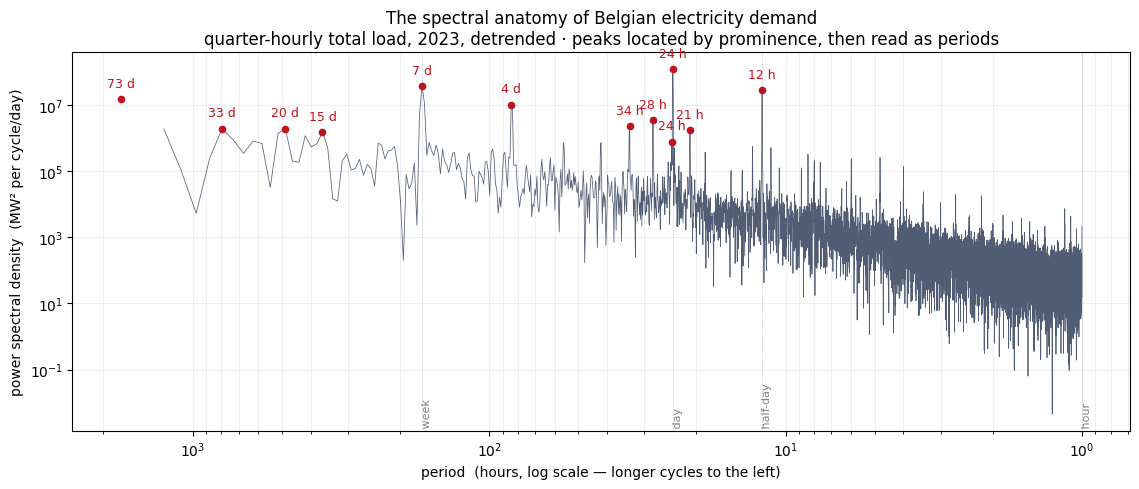

12 structural components carry 43.3% of the density in the resolved band


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 08 · §4 · Figure — the spectral anatomy of Belgian demand      v1.0.0
# provides ▸ —   ·   requires ▸ FRQ · PSD · PEAKS · plt
# ══════════════════════════════════════════════════════════════════════════
per_h = np.divide(24.0, FRQ, out=np.full_like(FRQ, np.inf), where=FRQ > 0)
m = (per_h >= 1.0) & (per_h <= 24 * 60)

fig, ax = plt.subplots(figsize=(11.5, 5.0))
ax.plot(per_h[m], PSD[m], lw=.55, color="#33415c", alpha=.85)
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()                                   # long cycles on the left

for _, r in PEAKS[PEAKS["share"] >= 1e-3].iterrows():
    ax.plot(r["period_h"], r["psd"], "o", ms=4.5, color="#c1121f", zorder=5)
    lab = (f"{r['period_d']:.0f} d" if r["period_d"] >= 1.5
           else f"{r['period_h']:.0f} h")
    ax.annotate(lab, (r["period_h"], r["psd"]), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9, color="#c1121f")

for p, lab in [(24 * 7, "week"), (24, "day"), (12, "half-day"), (1, "hour")]:
    ax.axvline(p, color="grey", lw=.6, ls=":", alpha=.6)
    ax.text(p, ax.get_ylim()[0], f" {lab}", rotation=90, va="bottom",
            fontsize=8, color="grey")

ax.set(xlabel="period  (hours, log scale — longer cycles to the left)",
       ylabel="power spectral density  (MW² per cycle/day)",
       title="The spectral anatomy of Belgian electricity demand\n"
             "quarter-hourly total load, 2023, detrended · peaks located by "
             "prominence, then read as periods")
ax.grid(alpha=.2, which="both")
plt.tight_layout()
plt.savefig("../figures/spectral_anatomy.png", dpi=200, bbox_inches="tight")
plt.show()

carried = PEAKS.loc[PEAKS["share"] >= 1e-3, "share"].sum()
print(f"{int((PEAKS['share'] >= 1e-3).sum())} structural components carry "
      f"{carried:.1%} of the density in the resolved band")


### 4. What the spectrum does and does not license

The periodogram is a variance decomposition, not a statement about
predictability. A sharp peak says that a periodic component explains a large
share of the *historical* variance; it does not say that a model built on that
component will forecast well out of sample. Three specific limits apply here.

**Resolution.** One year of quarter-hourly data gives a bin width of 1/365
cycles per day. The daily cycle and its harmonics land on bin centres exactly;
the weekly cycle does not, because 365/7 is not an integer, so its power is
spread across neighbouring bins and its apparent amplitude is understated. The
annual cycle cannot be resolved at all from a single year — it is one period
of the record, indistinguishable from the trend that detrending removes. Any
seasonal effect therefore has to enter a forecasting model through calendar
terms, not through the spectrum.

**Civil time versus physical time.** The transform runs on the UTC axis, which
is uniform in physical time. Human demand follows the Belgian civil clock,
which shifts by an hour twice a year. The daily peak is consequently smeared
by a small amount that no windowing can remove; it is a property of the
phenomenon, not of the estimator.

**Stationarity.** A periodogram over a full year assumes the periodic structure
is stable across it. Belgian load is not: the shape of a January weekday and a
July weekday differ in amplitude and in timing. The spectrum reports the
average structure and will therefore justify a *starting* set of harmonics, not
a final one.

What the spectrum does license is a short, defensible list of frequencies for
transparent Fourier terms, chosen from the data rather than from convention,
together with the honest expectation that periodicity alone will not carry a
day-ahead forecast. Whether it does is the question the next increment tests
against seasonal-naive benchmarks — and a negative answer there is a result,
not a failure.


In [9]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 09 · §5 · Persistence baselines on the civil clock              v1.0.0
# provides ▸ LH · B · BASELINES   ·   requires ▸ S · seasonal_naive · HOL
# ══════════════════════════════════════════════════════════════════════════
# Two transparent baselines: the same clock time yesterday, and the same clock
# time last week. Matched on the civil key rather than by shifting 96 or 672
# rows, because the civil day holds 92 or 100 quarters at the transitions and a
# fixed row offset would quietly reuse the wrong hour twice a year.
#
# The baselines need history from before the analysis window. Without a warm-up
# the first week of January has no previous-week forecast at all — and January
# is where Elia's own bias is largest, so dropping it would tilt the comparison.
# The cached pull already spans a month either side, so the warm-up is free.

WARMUP = pd.Timedelta(days=14)
LH, dropped_hist = complete_civil_days(S, START - WARMUP, END, TZ, FREQ)
LH["is_holiday"] = LH["civil_date"].isin(be_holidays(sorted({*LH["civil_date"].dt.year})))
print(f"history frame: {len(LH)} slots, {LH['civil_date'].nunique()} civil days, "
      f"{LH['civil_date'].min():%Y-%m-%d} .. {LH['civil_date'].max():%Y-%m-%d}")

BASELINES = {"pd1": ("previous day (D-1)", 1),
             "pw7": ("previous week (D-7)", 7)}

for col, (label, lag) in BASELINES.items():
    b = seasonal_naive(LH, lag)
    LH[col] = b["yhat"]
    LH[f"{col}_src"] = b["source_time"]

# Evaluation is restricted to the analysis window; the warm-up only feeds it.
B = LH[LH["civil_date"].between(START, END)].reset_index(drop=True)
B["daytype"] = np.where(B["is_holiday"], "holiday",
                np.where(B["is_weekend"], "weekend", "working day"))

print(f"\nevaluation frame: {len(B)} slots over {B['civil_date'].nunique()} civil days")
for col, (label, _) in BASELINES.items():
    na = B[col].isna()
    print(f"  {label:22s} unavailable {int(na.sum()):3d}")
    if na.any():
        print(B.loc[na, ["datetime", "civil_date", "qod"]]
                .assign(reason=np.where(B.loc[na, "qod"].between(8, 11),
                                        "spring-forward gap in source",
                                        "source observation missing"))
                .to_string(index=False))
print(f"\nmissing target load in the window: {int(B['y'].isna().sum())} "
      f"— availability of a forecast and presence of a target are separate")


history frame: 36384 slots, 379 civil days, 2022-12-18 .. 2023-12-31

evaluation frame: 35040 slots over 365 civil days
  previous day (D-1)     unavailable   7
                 datetime civil_date  qod                       reason
2023-03-27 00:00:00+00:00 2023-03-27    8 spring-forward gap in source
2023-03-27 00:15:00+00:00 2023-03-27    9 spring-forward gap in source
2023-03-27 00:30:00+00:00 2023-03-27   10 spring-forward gap in source
2023-03-27 00:45:00+00:00 2023-03-27   11 spring-forward gap in source
2023-08-11 09:00:00+00:00 2023-08-11   44   source observation missing
2023-08-12 09:00:00+00:00 2023-08-12   44   source observation missing
2023-09-12 09:00:00+00:00 2023-09-12   44   source observation missing
  previous week (D-7)    unavailable   7
                 datetime civil_date  qod                       reason
2023-04-02 00:00:00+00:00 2023-04-02    8 spring-forward gap in source
2023-04-02 00:15:00+00:00 2023-04-02    9 spring-forward gap in source
2023-04-02 00:30:

In [10]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 10 · §5 · Temporal-integrity audit against the forecast origin  v1.2.0
# provides ▸ ORIGIN · VIOL   ·   requires ▸ B · daily_origin · origin_violations
# ══════════════════════════════════════════════════════════════════════════
# The origin is 18:00 civil on D-1: the ODS001 schema identifies this column as
# the Day-ahead 6PM forecast (see CELL 01). Every value a forecast uses must
# predate it. This is checked, not asserted — and one baseline does not pass.

ORIGIN = daily_origin(B["civil_date"], ORIGIN_CIVIL_HOUR, lead_days=1, tz=TZ)
VIOL = {}
for col, (label, _) in BASELINES.items():
    v = origin_violations(B[f"{col}_src"], ORIGIN)
    VIOL[col] = v
    tail = f", worst {v['late_by'].max()} after the origin" if len(v) else ""
    print(f"{label:22s} source values after origin: {len(v):6d} of {len(B)}{tail}")

late = len(VIOL["pd1"])
print(f"\nD-1 draws on the evening of the source day, which postdates an 18:00 "
      f"origin: {late} of {len(B)} values ({late / len(B):.0%}).")
print("It is therefore an INFORMED baseline, admissible only under an origin at "
      "the day boundary. D-7 is clean at the stated origin and is the "
      "operational baseline.")

# --- robustness: would an earlier operational origin change the reading? ----
# Elia's general load documentation has quoted other update times. Those do not
# describe this column, but running the audit at each shows the conclusion does
# not rest on the choice.
print("\n--- robustness to alternative published issue times ---")
rows = []
for name, hour in ORIGIN_CANDIDATES.items():
    o = daily_origin(B["civil_date"], hour, lead_days=1, tz=TZ)
    r = {"origin": name}
    for col, (label, _) in BASELINES.items():
        v = origin_violations(B[f"{col}_src"], o)
        r[f"{label} violations"] = len(v)
        r[f"{label} worst"] = str(v["late_by"].max()) if len(v) else "-"
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False))
print("\nD-7 is leakage-free under every candidate origin, while D-1 is at least "
      "partly informed under all of them. The operational reading is therefore "
      "robust to the alternative publication-time documentation.")


previous day (D-1)     source values after origin:   8395 of 35040, worst 0 days 05:45:00 after the origin
previous week (D-7)    source values after origin:      0 of 35040

D-1 draws on the evening of the source day, which postdates an 18:00 origin: 8395 of 35040 values (24%).
It is therefore an INFORMED baseline, admissible only under an origin at the day boundary. D-7 is clean at the stated origin and is the operational baseline.

--- robustness to alternative published issue times ---


                                  origin  previous day (D-1) violations previous day (D-1) worst  previous week (D-7) violations previous week (D-7) worst
08:45 (Elia load page, earlier revision)                          21900          0 days 15:00:00                               0                         -
         12:00 (Elia load page, current)                          17155          0 days 11:45:00                               0                         -
         18:00 (ODS001 schema — primary)                           8395          0 days 05:45:00                               0                         -

D-7 is leakage-free under every candidate origin, while D-1 is at least partly informed under all of them. The operational reading is therefore robust to the alternative publication-time documentation.


In [11]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 11 · §5 · Common-sample evaluation against the Elia reference   v1.0.0
# provides ▸ COMMON · POINT · by_col   ·   requires ▸ B · score_point
# ══════════════════════════════════════════════════════════════════════════
# Metrics computed over different timestamp sets are not comparable, so every
# model is scored on the slots where all of them exist.

MODELS = {"pd1": "previous day (D-1)", "pw7": "previous week (D-7)",
          "yhat_da": "Elia day-ahead"}

COMMON = B.dropna(subset=["y", *MODELS]).copy()
print(f"common sample: {len(COMMON)} of {len(B)} slots "
      f"({len(B) - len(COMMON)} dropped for a missing target or forecast)")

POINT = pd.DataFrame([score_point(COMMON, y="y", yhat=c).rename(lab)
                      for c, lab in MODELS.items()])[["n_point", "bias", "MAE", "RMSE"]]
print("\npoint accuracy on the common sample, 2023 (MW; error = actual - forecast)")
print(POINT.round(1).to_string())

ref = POINT.loc["previous week (D-7)", "MAE"]
print(f"\nMAE relative to the previous-week baseline:")
for lab, r in POINT.iterrows():
    print(f"  {lab:22s} {r['MAE']:7.1f}   {100 * (1 - r['MAE'] / ref):+6.1f}%")

def by_col(key, label=None):
    t = pd.DataFrame({lab: COMMON.groupby(key)
                              .apply(lambda g: score_point(g, y="y", yhat=c)["MAE"])
                      for c, lab in MODELS.items()})
    print(f"\n--- MAE by {label or key} (MW) ---")
    print(t.round(1).to_string())
    return t

by_daytype = by_col("daytype", "day type")
by_dow     = by_col("dow", "weekday (0 = Monday)")
by_hourly  = by_col("hour", "civil hour")


common sample: 35024 of 35040 slots (16 dropped for a missing target or forecast)

point accuracy on the common sample, 2023 (MW; error = actual - forecast)
                     n_point  bias    MAE   RMSE
previous day (D-1)   35024.0  -0.3  482.3  706.1
previous week (D-7)  35024.0  -4.2  433.8  594.9
Elia day-ahead       35024.0 -59.9  259.9  342.0

MAE relative to the previous-week baseline:
  previous day (D-1)       482.3    -11.2%
  previous week (D-7)      433.8     +0.0%
  Elia day-ahead           259.9    +40.1%

--- MAE by day type (MW) ---
             previous day (D-1)  previous week (D-7)  Elia day-ahead
daytype                                                             
holiday                   656.2               1310.4           329.0
weekend                   596.4                383.6           254.9
working day               428.8                419.4           259.2

--- MAE by weekday (0 = Monday) (MW) ---
     previous day (D-1)  previous week (D-7)  Elia day-a

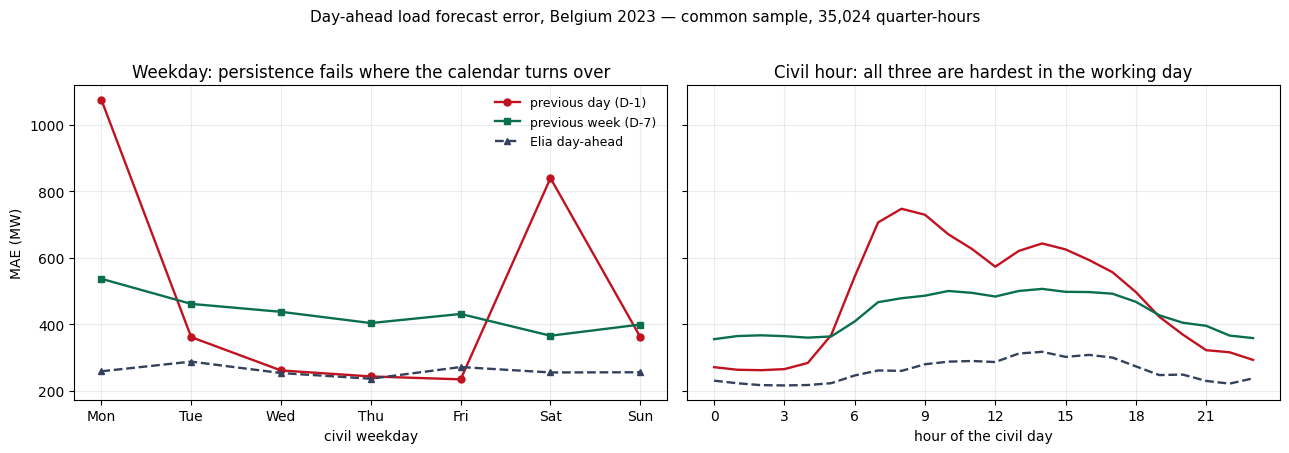

In [12]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 12 · §5 · Figure — where the persistence baselines break down   v1.0.0
# provides ▸ —   ·   requires ▸ by_dow · by_hourly · plt
# ══════════════════════════════════════════════════════════════════════════
# Not another time series: the two panels that carry the finding. Weekday shows
# why matching the calendar beats matching the clock; hour shows that both fail
# in the same part of the day.

STYLE = {"previous day (D-1)": ("#c1121f", "-", "o"),
         "previous week (D-7)": ("#0b6e4f", "-", "s"),
         "Elia day-ahead": ("#33415c", "--", "^")}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)

for lab, (col, ls, mk) in STYLE.items():
    axes[0].plot(by_dow.index, by_dow[lab], color=col, ls=ls, marker=mk, ms=5, lw=1.7,
                 label=lab)
axes[0].set(title="Weekday: persistence fails where the calendar turns over",
            xlabel="civil weekday", ylabel="MAE (MW)")
axes[0].set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=.25)

for lab, (col, ls, mk) in STYLE.items():
    axes[1].plot(by_hourly.index, by_hourly[lab], color=col, ls=ls, lw=1.7, label=lab)
axes[1].set(title="Civil hour: all three are hardest in the working day",
            xlabel="hour of the civil day")
axes[1].set_xticks(range(0, 24, 3))
axes[1].grid(alpha=.25)

fig.suptitle("Day-ahead load forecast error, Belgium 2023 — common sample, "
             f"{len(COMMON):,} quarter-hours", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("../figures/baseline_error.png", dpi=200, bbox_inches="tight")
plt.show()


### 5. How hard is day-ahead load forecasting, and what does Elia buy?

Three results, in the order they matter.

**The previous-week baseline beats the previous-day baseline.** That is not the
usual ordering for persistence forecasts, and it is not an artefact. Belgian
load is shaped as much by the calendar as by the clock: a Monday resembles last
Monday far more than it resembles Sunday. The weekday panel shows exactly where
D-1 loses — Monday and Saturday, the two days whose predecessor belongs to a
different regime — while D-7 stays flat across the week because it preserves the
weekday by construction. The one place D-7 is much worse is public holidays,
where the day a week earlier was an ordinary working day and D-1 at least
inherits a nearby seasonal level.

**The comparison with D-1 is generous to D-1, and it still loses.** The forecast
origin is 18:00 civil on D-1. That is not an assumption: the ODS001 schema
identifies the column this study uses as the "Day-ahead 6PM forecast", with
"Day-ahead 6PM P10" and "Day-ahead 6PM P90" alongside it, so 18:00 Europe/Brussels
is the issue time for these fields. At that origin the audit in CELL 10 finds
that 24% of D-1 forecast values draw on observations that did not yet exist —
the evening of the source day, by at most 5h45. D-1 is therefore reported as an
informed baseline: admissible only under an origin at the day boundary, and not
a like-for-like competitor to a forecast issued at six in the evening. Its error
is optimistic relative to a fair same-origin comparison — and it is beaten anyway.

Elia's general grid-data page for load quotes other update times for a
day-ahead load forecast — midday now, 08:45 in an earlier revision. That page
documents the load graph on the Elia website rather than these columns, so it is
not a competing reading of the field. It does motivate a robustness check, and
CELL 10 runs the audit at all three times. The D-1 violation grows as the origin
moves earlier (8,395 at 18:00, 17,155 at 12:00, 21,900 at 08:45) while D-7 stays
leakage-free at every one of them. The substantive conclusion — D-7 is the clean
operational baseline and D-1 is at least partly informed — holds under any of the
documented times. And none of it touches the numbers: the origin governs which
baseline is admissible, not what any forecast predicts, so every accuracy figure
below is unchanged.

**Elia's operational forecast is roughly forty per cent better than the best
naive baseline, and it is not a fair fight either.** Elia has weather forecasts,
outage schedules and nominations that none of this uses; the point of the
comparison is not to score a contest but to bound how much of day-ahead
predictability is available from the load history alone, and how much requires
exogenous information. The answer is that persistence gets you a long way — the
gap between the naive baselines and the operational forecast is smaller than the
gap between either and a perfect forecast — but the remaining error is
concentrated in the working day, where all three methods are worst.

Nothing here revises the spectral result. The strong daily and weekly components
found in §4 are exactly what makes persistence work at all; the weekday panel is
the same weekly structure seen through forecast error rather than through
variance. What §4 could not tell us, and this section does, is that periodicity
alone leaves a substantial error that only exogenous information appears to
close — which is the question the next increment has to confront.


In [13]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 13 · §6 · Fourier + calendar model, refit at each origin        v1.0.0
# provides ▸ FIT · B   ·   requires ▸ LH · B · SPEC · forecast_by_origin
# ══════════════════════════════════════════════════════════════════════════
# The model is written down before it is estimated, and never searched over.
# Harmonic counts are the first K harmonics of the day and the week — periods
# that follow from the calendar. They are NOT read off the §4 spectrum: that
# periodogram was estimated on the whole of 2023, so choosing frequencies from
# it would leak the evaluation period into the specification.

print("model:", SPEC.describe())
print(f"design columns: {design_matrix(LH.head(1)).shape[1]}")
print("\nno annual harmonic: with about a month of history before the evaluation "
      "window\nbegins, a yearly cycle is not identifiable and fitting one would "
      "extrapolate\na period the data cannot support. Seasonal level is carried by "
      "the estimation\nwindow instead, and both protocols are reported so that "
      "choice stays visible.")

PROTOCOLS = {"fourier_roll": ("Fourier+calendar, 56-day window", 56),
             "fourier_exp":  ("Fourier+calendar, expanding",     None)}

for col, (label, window) in PROTOCOLS.items():
    fit = forecast_by_origin(LH, targets=B["civil_date"].unique(), spec=SPEC,
                             origin_civil_hour=ORIGIN_CIVIL_HOUR, lead_days=1,
                             tz=TZ, window_days=window, min_history_days=28)
    LH[col] = fit["yhat"]
    if col == "fourier_roll":
        FIT = fit
    print(f"\n{label}: {int(fit['available'].sum())} of {len(LH)} slots forecast")

B = LH[LH["civil_date"].between(START, END)].reset_index(drop=True)
B["daytype"] = np.where(B["is_holiday"], "holiday",
                np.where(B["is_weekend"], "weekend", "working day"))
for col, (label, _) in PROTOCOLS.items():
    na = B[col].isna()
    print(f"{label:34s} unavailable in 2023: {int(na.sum()):4d}"
          + (f"  (first {B.loc[na, 'civil_date'].min():%Y-%m-%d}, "
             f"last {B.loc[na, 'civil_date'].max():%Y-%m-%d})" if na.any() else ""))


model: daily harmonics 24h, 12h, 8h, 6h estimated separately for working and non-working days; weekly harmonics 168h, 84h, 56h; intercept and a non-working level term; ordinary least squares
design columns: 24

no annual harmonic: with about a month of history before the evaluation window
begins, a yearly cycle is not identifiable and fitting one would extrapolate
a period the data cannot support. Seasonal level is carried by the estimation
window instead, and both protocols are reported so that choice stays visible.



Fourier+calendar, 56-day window: 33600 of 36384 slots forecast



Fourier+calendar, expanding: 33600 of 36384 slots forecast
Fourier+calendar, 56-day window    unavailable in 2023: 1440  (first 2023-01-01, last 2023-01-15)
Fourier+calendar, expanding        unavailable in 2023: 1440  (first 2023-01-01, last 2023-01-15)


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 14 · §6 · Temporal-integrity audit of the fitted model          v1.0.0
# provides ▸ —   ·   requires ▸ FIT · B · origin_violations
# ══════════════════════════════════════════════════════════════════════════
# A model refit per day is exposed to a failure the baselines are not: the fit
# window quietly including the day it is asked to predict. Checked here on the
# real run, not only in the unit tests.

A_FIT = FIT.loc[FIT["available"]]
tgt_start = (LH.loc[FIT["available"], ["civil_date"]]
               .assign(t=LH.loc[FIT["available"], "datetime"])
               .groupby("civil_date")["t"].transform("min"))

print(f"fitted days: {A_FIT['origin'].nunique()}")
print(f"fit window ends after its origin:      "
      f"{int((A_FIT['fit_end'] > A_FIT['origin']).sum())}")
print(f"fit window reaches its own target day: "
      f"{int((A_FIT['fit_end'] >= tgt_start).sum())}")
print(f"rows used per fit: {A_FIT['n_fit'].min():.0f} .. {A_FIT['n_fit'].max():.0f} "
      f"(56 days = {56 * 96} slots)")
print(f"worst gap between fit end and target start: "
      f"{(tgt_start - A_FIT['fit_end']).min()}")

assert (A_FIT["fit_end"] <= A_FIT["origin"]).all(), "fit window crosses the origin"
assert (A_FIT["fit_end"] < tgt_start).all(), "fit window reaches the target day"
print("\ntemporal integrity holds on the real run for every fitted day")


fitted days: 350
fit window ends after its origin:      0
fit window reaches its own target day: 0
rows used per fit: 2761 .. 5376 (56 days = 5376 slots)
worst gap between fit end and target start: 0 days 06:00:00

temporal integrity holds on the real run for every fitted day


In [15]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 15 · §6 · Common-sample comparison with D-7 and Elia            v1.0.0
# provides ▸ COMMON6 · POINT6   ·   requires ▸ B · score_point
# ══════════════════════════════════════════════════════════════════════════
MODELS6 = {"pw7": "previous week (D-7)",
           "fourier_roll": "Fourier+calendar (56d)",
           "fourier_exp": "Fourier+calendar (expanding)",
           "yhat_da": "Elia day-ahead"}

COMMON6 = B.dropna(subset=["y", *MODELS6]).copy()
print(f"common sample: {len(COMMON6)} of {len(B)} slots "
      f"({len(B) - len(COMMON6)} dropped for a missing target or forecast)")

POINT6 = pd.DataFrame([score_point(COMMON6, y="y", yhat=c).rename(lab)
                       for c, lab in MODELS6.items()])[["n_point", "bias", "MAE", "RMSE"]]
ref = POINT6.loc["previous week (D-7)", "MAE"]
POINT6["vs D-7 %"] = 100 * (1 - POINT6["MAE"] / ref)
print("\npoint accuracy on the common sample (MW; error = actual - forecast)")
print(POINT6.round(1).to_string())

def by6(key, label=None):
    t = pd.DataFrame({lab: COMMON6.groupby(key)
                              .apply(lambda g: score_point(g, y="y", yhat=c)["MAE"])
                      for c, lab in MODELS6.items()})
    print(f"\n--- MAE by {label or key} (MW) ---")
    print(t.round(1).to_string())
    return t

# --- where the error lives: the level of the day, or its shape? ------------
# Attribution, not a model change. Each error is split into the mean error over
# its target civil day and the remainder within the day. If a forecast has the
# shape right but the level wrong, the first term dominates — and that is a
# different deficiency, with a different remedy, from getting the shape wrong.
print("\n--- error decomposition, MAE (MW) ---")
rows = []
for col, lab in MODELS6.items():
    e = COMMON6["y"] - COMMON6[col]
    level = e.groupby(COMMON6["civil_date"]).transform("mean")
    rows.append({"model": lab, "MAE": e.abs().mean(),
                 "day-level": level.abs().mean(),
                 "within-day shape": (e - level).abs().mean(),
                 "level share of var": level.var() / e.var()})
print(pd.DataFrame(rows).set_index("model").round(2).to_string())

by6_daytype = by6("daytype", "day type")
by6_hour    = by6("hour", "civil hour")


common sample: 33590 of 35040 slots (1450 dropped for a missing target or forecast)

point accuracy on the common sample (MW; error = actual - forecast)
                              n_point   bias    MAE   RMSE  vs D-7 %
previous week (D-7)           33590.0  -35.7  418.7  578.5       0.0
Fourier+calendar (56d)        33590.0   23.7  558.8  691.5     -33.4
Fourier+calendar (expanding)  33590.0 -259.7  728.9  887.3     -74.1
Elia day-ahead                33590.0  -66.7  257.9  339.5      38.4

--- error decomposition, MAE (MW) ---
                                 MAE  day-level  within-day shape  level share of var
model                                                                                
previous week (D-7)           418.73     370.16            206.91                0.76
Fourier+calendar (56d)        558.78     530.41            191.83                0.87
Fourier+calendar (expanding)  728.89     703.87            222.66                0.89
Elia day-ahead                257

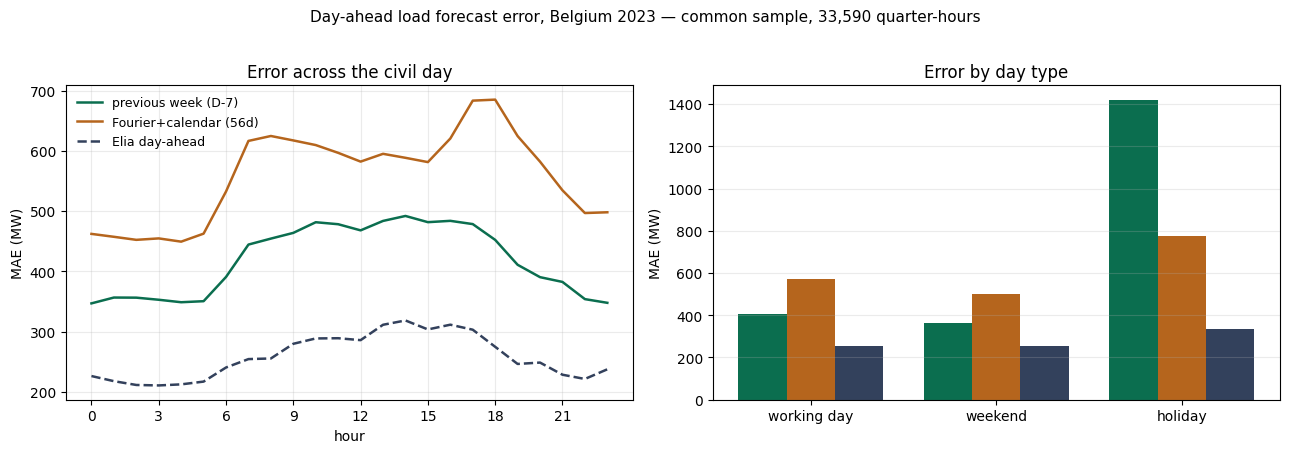

In [16]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 16 · §6 · Figure — what the harmonic model buys, and where      v1.0.0
# provides ▸ —   ·   requires ▸ by6_hour · by6_daytype · plt
# ══════════════════════════════════════════════════════════════════════════
SHOW = ["previous week (D-7)", "Fourier+calendar (56d)", "Elia day-ahead"]
COLOUR = {"previous week (D-7)": "#0b6e4f", "Fourier+calendar (56d)": "#b5651d",
          "Elia day-ahead": "#33415c"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for lab in SHOW:
    axes[0].plot(by6_hour.index, by6_hour[lab], color=COLOUR[lab], lw=1.8,
                 ls="--" if lab == "Elia day-ahead" else "-", label=lab)
axes[0].set(title="Error across the civil day", xlabel="hour", ylabel="MAE (MW)")
axes[0].set_xticks(range(0, 24, 3)); axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=.25)

order = ["working day", "weekend", "holiday"]
x = np.arange(len(order)); w = 0.26
for i, lab in enumerate(SHOW):
    axes[1].bar(x + (i - 1) * w, by6_daytype.loc[order, lab], w,
                color=COLOUR[lab], label=lab)
axes[1].set(title="Error by day type", ylabel="MAE (MW)")
axes[1].set_xticks(x, order); axes[1].grid(alpha=.25, axis="y")

fig.suptitle("Day-ahead load forecast error, Belgium 2023 — common sample, "
             f"{len(COMMON6):,} quarter-hours", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fourier_error.png", dpi=200, bbox_inches="tight")
plt.show()


### 6. What a transparent Fourier and calendar model adds, and what it cannot

**It loses to the persistence baseline, and the reason is precise.** On the
common sample the harmonic model reaches MAE 558.8 MW against 418.7 for D-7 —
33% worse — and the expanding-window variant is worse still at 728.9. Taken at
face value that reads as a failure of the spectral programme. The error
decomposition says otherwise.

Splitting each error into the mean error over its target day and the remainder within the day shows where the model fails. For the Fourier model, 87% of the error variance sits in the day-level term. After removing each day's realised mean error ex post, the remaining within-day error is 191.8 MW, compared with 206.9 MW for D-7 and 159.3 MW for Elia. This diagnostic suggests that the Fourier model captures intraday structure reasonably well, but that its dominant weakness is positioning the overall load level of the target day.

That distinction matters. Harmonics and calendar terms describe recurring shape; they contain little information about whether tomorrow's overall load level will be unusually high or low. Weekly persistence inherits some of that level information from the previous week, which explains why it remains materially better in overall MAE.

That is the answer to the question this increment asked. Beyond D-7, the transparent Fourier and calendar model does not improve overall point accuracy. Its error decomposition nevertheless suggests that the main missing component is not intraday shape but day-level positioning.

**Two places where the calendar terms clearly earn their keep.** On public
holidays the model reaches 777 MW against D-7's 1418: treating a holiday as
non-working fixes exactly the failure §5 identified, where the day a week
earlier was an ordinary working day. And the model produces a forecast for every
slot of both DST days and for slots whose history is missing, where persistence
cannot — its 1,440 unavailable slots in 2023 are the first fifteen days only,
where the estimation window has not yet accumulated the required history.

**The expanding window is the diagnostic, not a contender.** With no annual
harmonic — unidentifiable from the month of history available before the
evaluation window — an expanding fit averages over ever more of the year and
drifts badly, ending at a bias of −260 MW against the rolling window's +24. The
comparison isolates the same point from the other side: the model's accuracy is
governed by how it acquires level, not by its harmonic content.

None of this revises §4 or §5. The spectrum said periodicity is strong
descriptively and would not by itself carry a day-ahead forecast; the shape
result confirms the first half and the level result confirms the second. The
obvious next step is the one this increment deliberately did not take.
